In [102]:
import os
import time
import requests
import json
import cv2
from datetime import datetime
from IPython.display import Image, display, clear_output

AI_SERVER_URL = "http://localhost:8000/api/detect"
MOCK_CCTV_ID = "CCTV_JUPYTER_001"
FOLDER_PATH = "../dataset/snapshot4" 
OUTPUT_FOLDER = os.path.join(FOLDER_PATH, "detect_results")
valid_extensions = ('.jpg', '.jpeg', '.png')

In [103]:
if os.path.exists(FOLDER_PATH):
    images = [f for f in os.listdir(FOLDER_PATH) if f.lower().endswith(valid_extensions)]
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    print(f"총 {len(images)}개 이미지")
else:
    images = []

총 16개 이미지


처리 완료: snapshot_006.jpg


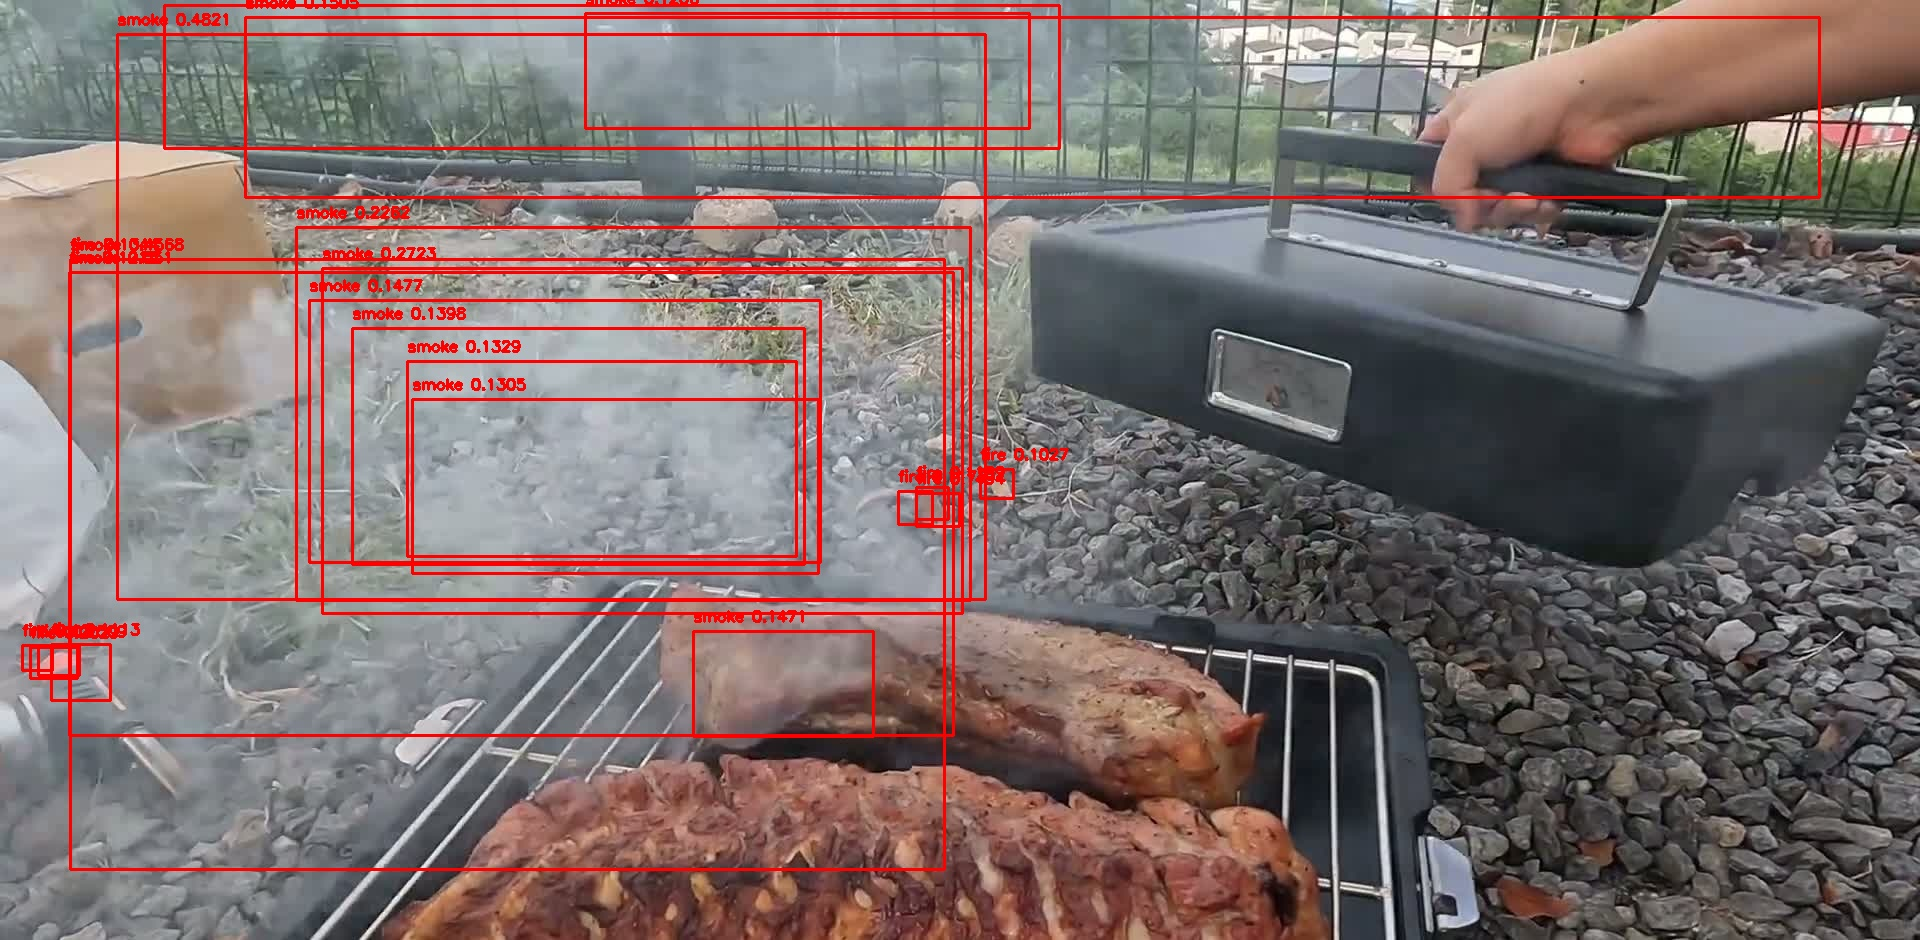

탐지 객체 수: 23개
서버 연결 실패


In [104]:
if not images:
    print("이미지를 찾을 수 없습니다.")
else:
    for img_filename in images:
        img_path = os.path.join(FOLDER_PATH, img_filename)
        base_name, ext = os.path.splitext(img_filename)
        
        form_data = {
            "imageId": base_name,
            "capturedAt": datetime.now().isoformat()
        }

        try:
            with open(img_path, 'rb') as f:
                files = {"image": (img_filename, f, f"image/{ext.replace('.','')}")}
                response = requests.post(AI_SERVER_URL, data=form_data, files=files)

            if response.status_code == 200:
                result_json = response.json()
                boxes = result_json['result']['boxes']
                is_detected = result_json['result']['detected']
                
                result_txt_path = os.path.join(OUTPUT_FOLDER, f"{base_name}.json")
                with open(result_txt_path, 'w', encoding='utf-8') as txt_file:
                    json.dump(result_json, txt_file, ensure_ascii=False, indent=4)
                
                img = cv2.imread(img_path)
                for box in boxes:
                    x, y, w, h = int(box['x']), int(box['y']), int(box['width']), int(box['height'])
                    label = f"{box['label']} {box['score']}"
                    
                    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                
                vis_img_path = os.path.join(OUTPUT_FOLDER, f"{base_name}_result.jpg")
                cv2.imwrite(vis_img_path, img)
                
                clear_output(wait=True)
                print(f"처리 완료: {img_filename}")
                display(Image(filename=vis_img_path, width=400))
                
                if is_detected:
                    print(f"탐지 객체 수: {len(boxes)}개")
                else:
                    print("특이사항 없음.")
                    
        except requests.exceptions.ConnectionError:
            print("서버 연결 실패")
            break 
        except Exception as e:
            print(f"오류 발생: {str(e)}")

        time.sleep(3)